In [21]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from jax import random
from scipy.linalg import eigvalsh
from ntk import compute_ntk_nngp_recursive, relu, relu_dot
from tqdm import tqdm

# Experiment: NTK Spectrum Analysis with Phase Transition

We analyze the eigenvalue spectrum of Neural Tangent Kernels to find stable growth regimes:
1. First identify (sigma_A, sigma_c) pairs that give stable growth
2. Plot spectrum for a stable configuration and analyze growth rates

Testing σA values:   0%|          | 0/14 [00:00<?, ?it/s]


Testing depth 1 for σA=0.01, σc=0.01


[[6.8479941e+03 4.7972366e-01 9.6946186e-01 6.0817820e-01 3.8611197e-01
  4.0679851e-01 5.5068892e-01 7.6929981e-01]
 [4.7972366e-01 6.8479941e+03 6.0313678e-01 5.7070237e-01 6.2359738e-01
  8.7429577e-01 6.7350405e-01 4.0169042e-01]
 [9.6946186e-01 6.0313678e-01 6.8479941e+03 5.3690422e-01 3.9480701e-01
  4.6212989e-01 5.6112963e-01 6.6836286e-01]
 [6.0817820e-01 5.7070237e-01 5.3690422e-01 6.8479941e+03 4.7615850e-01
  6.8215466e-01 5.4816192e-01 6.3046080e-01]
 [3.8611197e-01 6.2359738e-01 3.9480701e-01 4.7615850e-01 6.8479941e+03
  7.4183780e-01 7.7359325e-01 5.1343662e-01]
 [4.0679851e-01 8.7429577e-01 4.6212989e-01 6.8215466e-01 7.4183780e-01
  6.8479941e+03 8.2273185e-01 3.5007709e-01]
 [5.5068892e-01 6.7350405e-01 5.6112963e-01 5.4816192e-01 7.7359325e-01
  8.2273185e-01 6.8479941e+03 4.1302693e-01]
 [7.6929981e-01 4.0169042e-01 6.6836286e-01 6.3046080e-01 5.1343662e-01
  3.5007709e-01 4.1302693e-01 6.8479941e+03]]
Testing depth 2 for σA=0.01, σc=0.01


[[2.8168482e+04 1.5295486e+00 1.5300143e+00 1.5299071e+00 1.5295210e+00
  1.5295273e+00 1.5298902e+00 1.5299550e+00]
 [1.5295486e+00 2.8168482e+04 1.5299058e+00 1.5298961e+00 1.5299116e+00
  1.5299859e+00 1.5299265e+00 1.5295256e+00]
 [1.5300143e+00 1.5299058e+00 2.8168482e+04 1.5298861e+00 1.5295237e+00
  1.5295436e+00 1.5298934e+00 1.5299251e+00]
 [1.5299071e+00 1.5298961e+00 1.5298861e+00 2.8168482e+04 1.5295477e+00
  1.5299292e+00 1.5298895e+00 1.5299137e+00]
 [1.5295210e+00 1.5299116e+00 1.5295237e+00 1.5295477e+00 2.8168482e+04
  1.5299467e+00 1.5299562e+00 1.5298791e+00]
 [1.5295273e+00 1.5299859e+00 1.5295436e+00 1.5299292e+00 1.5299467e+00
  2.8168482e+04 1.5299709e+00 1.5295103e+00]
 [1.5298902e+00 1.5299265e+00 1.5298934e+00 1.5298895e+00 1.5299562e+00
  1.5299709e+00 2.8168482e+04 1.5295290e+00]
 [1.5299550e+00 1.5295256e+00 1.5299251e+00 1.5299137e+00 1.5298791e+00
  1.5295103e+00 1.5295290e+00 2.8168482e+04]]
Testing depth 3 for σA=0.01, σc=0.01


[[9.9036047e+04 4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00
  4.6753573e+00 4.6753573e+00 4.6753573e+00]
 [4.6753573e+00 9.9036047e+04 4.6753573e+00 4.6753573e+00 4.6753573e+00
  4.6753573e+00 4.6753573e+00 4.6753573e+00]
 [4.6753573e+00 4.6753573e+00 9.9036047e+04 4.6753573e+00 4.6753573e+00
  4.6753573e+00 4.6753573e+00 4.6753573e+00]
 [4.6753573e+00 4.6753573e+00 4.6753573e+00 9.9036047e+04 4.6753573e+00
  4.6753573e+00 4.6753573e+00 4.6753573e+00]
 [4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00 9.9036047e+04
  4.6753573e+00 4.6753573e+00 4.6753573e+00]
 [4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00
  9.9036047e+04 4.6753573e+00 4.6753573e+00]
 [4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00
  4.6753573e+00 9.9036047e+04 4.6753573e+00]
 [4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00 4.6753573e+00
  4.6753573e+00 4.6753573e+00 9.9036047e+04]]
Testing depth 4 for σA=0.01, σc=0.01


[[3.5192669e+05 1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01
  1.5211593e+01 1.5211593e+01 1.5211593e+01]
 [1.5211593e+01 3.5192669e+05 1.5211593e+01 1.5211593e+01 1.5211593e+01
  1.5211593e+01 1.5211593e+01 1.5211593e+01]
 [1.5211593e+01 1.5211593e+01 3.5192669e+05 1.5211593e+01 1.5211593e+01
  1.5211593e+01 1.5211593e+01 1.5211593e+01]
 [1.5211593e+01 1.5211593e+01 1.5211593e+01 3.5192669e+05 1.5211593e+01
  1.5211593e+01 1.5211593e+01 1.5211593e+01]
 [1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01 3.5192669e+05
  1.5211593e+01 1.5211593e+01 1.5211593e+01]
 [1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01
  3.5192669e+05 1.5211593e+01 1.5211593e+01]
 [1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01
  1.5211593e+01 3.5192669e+05 1.5211593e+01]
 [1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01 1.5211593e+01
  1.5211593e+01 1.5211593e+01 3.5192669e+05]]
Testing depth 5 for σA=0.01, σc=0.01


[[1.1994320e+06 5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01
  5.2834755e+01 5.2834755e+01 5.2834755e+01]
 [5.2834755e+01 1.1994320e+06 5.2834755e+01 5.2834755e+01 5.2834755e+01
  5.2834755e+01 5.2834755e+01 5.2834755e+01]
 [5.2834755e+01 5.2834755e+01 1.1994320e+06 5.2834755e+01 5.2834755e+01
  5.2834755e+01 5.2834755e+01 5.2834755e+01]
 [5.2834755e+01 5.2834755e+01 5.2834755e+01 1.1994320e+06 5.2834755e+01
  5.2834755e+01 5.2834755e+01 5.2834755e+01]
 [5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01 1.1994320e+06
  5.2834755e+01 5.2834755e+01 5.2834755e+01]
 [5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01
  1.1994320e+06 5.2834755e+01 5.2834755e+01]
 [5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01
  5.2834755e+01 1.1994320e+06 5.2834755e+01]
 [5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01 5.2834755e+01
  5.2834755e+01 5.2834755e+01 1.1994320e+06]]
Testing depth 6 for σA=0.01, σc=0.01


[[4.2039800e+06 1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02
  1.7890201e+02 1.7890201e+02 1.7890201e+02]
 [1.7890201e+02 4.2039800e+06 1.7890201e+02 1.7890201e+02 1.7890201e+02
  1.7890201e+02 1.7890201e+02 1.7890201e+02]
 [1.7890201e+02 1.7890201e+02 4.2039800e+06 1.7890201e+02 1.7890201e+02
  1.7890201e+02 1.7890201e+02 1.7890201e+02]
 [1.7890201e+02 1.7890201e+02 1.7890201e+02 4.2039800e+06 1.7890201e+02
  1.7890201e+02 1.7890201e+02 1.7890201e+02]
 [1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02 4.2039800e+06
  1.7890201e+02 1.7890201e+02 1.7890201e+02]
 [1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02
  4.2039800e+06 1.7890201e+02 1.7890201e+02]
 [1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02
  1.7890201e+02 4.2039800e+06 1.7890201e+02]
 [1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02 1.7890201e+02
  1.7890201e+02 1.7890201e+02 4.2039800e+06]]


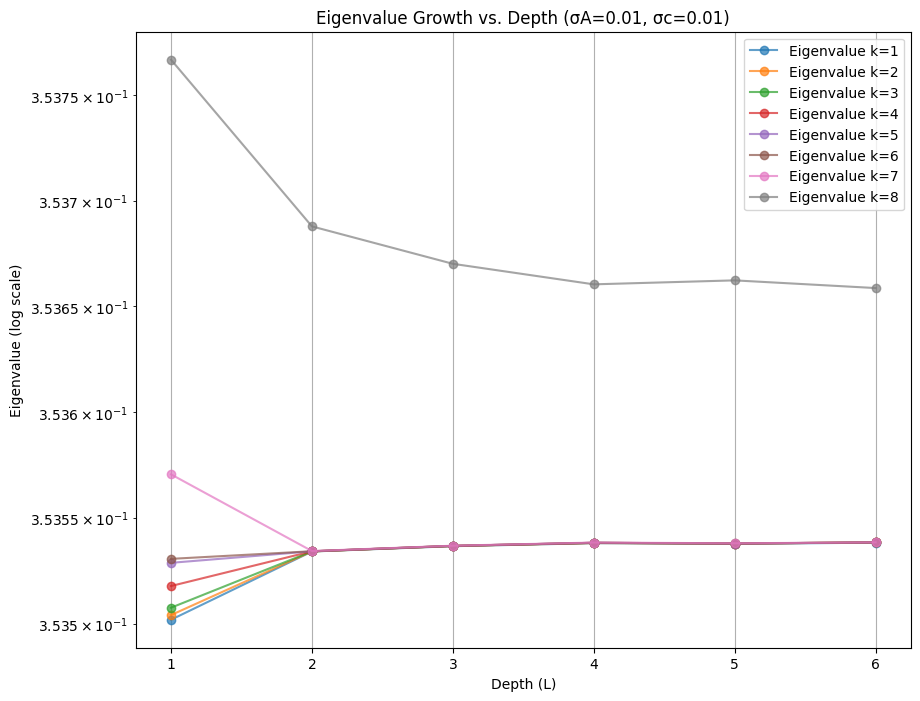

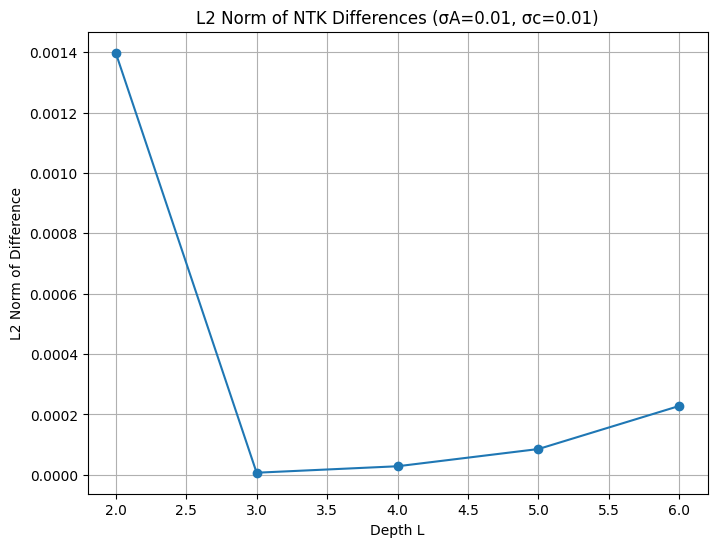

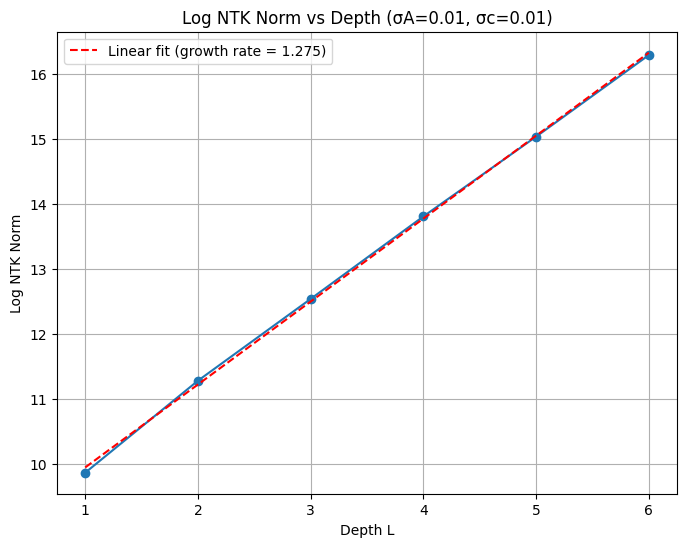

Error at σA=0.01, σc=0.01: log requires ndarray or scalar arguments, got <class 'list'> at position 0.


Testing depth 1 for σA=0.01, σc=0.05


[[6.8479966e+03 4.8212367e-01 9.7186184e-01 6.1057818e-01 3.8851199e-01
  4.0919852e-01 5.5308890e-01 7.7169979e-01]
 [4.8212367e-01 6.8479966e+03 6.0553676e-01 5.7310236e-01 6.2599736e-01
  8.7669575e-01 6.7590404e-01 4.0409043e-01]
 [9.7186184e-01 6.0553676e-01 6.8479966e+03 5.3930420e-01 3.9720702e-01
  4.6452990e-01 5.6352961e-01 6.7076284e-01]
 [6.1057818e-01 5.7310236e-01 5.3930420e-01 6.8479966e+03 4.7855851e-01
  6.8455464e-01 5.5056190e-01 6.3286078e-01]
 [3.8851199e-01 6.2599736e-01 3.9720702e-01 4.7855851e-01 6.8479966e+03
  7.4423778e-01 7.7599323e-01 5.1583660e-01]
 [4.0919852e-01 8.7669575e-01 4.6452990e-01 6.8455464e-01 7.4423778e-01
  6.8479966e+03 8.2513183e-01 3.5247710e-01]
 [5.5308890e-01 6.7590404e-01 5.6352961e-01 5.5056190e-01 7.7599323e-01
  8.2513183e-01 6.8479966e+03 4.1542694e-01]
 [7.7169979e-01 4.0409043e-01 6.7076284e-01 6.3286078e-01 5.1583660e-01
  3.5247710e-01 4.1542694e-01 6.8479966e+03]]
Testing depth 2 for σA=0.01, σc=0.05


[[2.8335475e+04 1.5404595e+00 1.5409290e+00 1.5408217e+00 1.5404320e+00
  1.5404381e+00 1.5408047e+00 1.5408696e+00]
 [1.5404595e+00 2.8335475e+04 1.5408204e+00 1.5408105e+00 1.5408263e+00
  1.5409009e+00 1.5408411e+00 1.5404365e+00]
 [1.5409290e+00 1.5408204e+00 2.8335475e+04 1.5408005e+00 1.5404345e+00
  1.5404545e+00 1.5408078e+00 1.5408397e+00]
 [1.5408217e+00 1.5408105e+00 1.5408005e+00 2.8335475e+04 1.5404586e+00
  1.5408438e+00 1.5408039e+00 1.5408285e+00]
 [1.5404320e+00 1.5408263e+00 1.5404345e+00 1.5404586e+00 2.8335475e+04
  1.5408612e+00 1.5408710e+00 1.5404698e+00]
 [1.5404381e+00 1.5409009e+00 1.5404545e+00 1.5408438e+00 1.5408612e+00
  2.8335475e+04 1.5408854e+00 1.5404211e+00]
 [1.5408047e+00 1.5408411e+00 1.5408078e+00 1.5408039e+00 1.5408710e+00
  1.5408854e+00 2.8335475e+04 1.5404398e+00]
 [1.5408696e+00 1.5404365e+00 1.5408397e+00 1.5408285e+00 1.5404698e+00
  1.5404211e+00 1.5404398e+00 2.8335475e+04]]
Testing depth 3 for σA=0.01, σc=0.05


[[1.0037673e+05 4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00
  4.7137356e+00 4.7137356e+00 4.7137356e+00]
 [4.7137356e+00 1.0037673e+05 4.7137356e+00 4.7137356e+00 4.7137356e+00
  4.7137356e+00 4.7137356e+00 4.7137356e+00]
 [4.7137356e+00 4.7137356e+00 1.0037673e+05 4.7137356e+00 4.7137356e+00
  4.7137356e+00 4.7137356e+00 4.7137356e+00]
 [4.7137356e+00 4.7137356e+00 4.7137356e+00 1.0037673e+05 4.7137356e+00
  4.7137356e+00 4.7137356e+00 4.7137356e+00]
 [4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00 1.0037673e+05
  4.7137356e+00 4.7137356e+00 4.7137356e+00]
 [4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00
  1.0037673e+05 4.7137356e+00 4.7137356e+00]
 [4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00
  4.7137356e+00 1.0037673e+05 4.7137356e+00]
 [4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00 4.7137356e+00
  4.7137356e+00 4.7137356e+00 1.0037673e+05]]
Testing depth 4 for σA=0.01, σc=0.05


[[3.6164041e+05 1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01
  1.5427626e+01 1.5427626e+01 1.5427626e+01]
 [1.5427626e+01 3.6164041e+05 1.5427626e+01 1.5427626e+01 1.5427626e+01
  1.5427626e+01 1.5427626e+01 1.5427626e+01]
 [1.5427626e+01 1.5427626e+01 3.6164041e+05 1.5427626e+01 1.5427626e+01
  1.5427626e+01 1.5427626e+01 1.5427626e+01]
 [1.5427626e+01 1.5427626e+01 1.5427626e+01 3.6164041e+05 1.5427626e+01
  1.5427626e+01 1.5427626e+01 1.5427626e+01]
 [1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01 3.6164041e+05
  1.5427626e+01 1.5427626e+01 1.5427626e+01]
 [1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01
  3.6164041e+05 1.5427626e+01 1.5427626e+01]
 [1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01
  1.5427626e+01 3.6164041e+05 1.5427626e+01]
 [1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01 1.5427626e+01
  1.5427626e+01 1.5427626e+01 3.6164041e+05]]
Testing depth 5 for σA=0.01, σc=0.05


[[1.2665640e+06 5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01
  5.4268692e+01 5.4268692e+01 5.4268692e+01]
 [5.4268692e+01 1.2665640e+06 5.4268692e+01 5.4268692e+01 5.4268692e+01
  5.4268692e+01 5.4268692e+01 5.4268692e+01]
 [5.4268692e+01 5.4268692e+01 1.2665640e+06 5.4268692e+01 5.4268692e+01
  5.4268692e+01 5.4268692e+01 5.4268692e+01]
 [5.4268692e+01 5.4268692e+01 5.4268692e+01 1.2665640e+06 5.4268692e+01
  5.4268692e+01 5.4268692e+01 5.4268692e+01]
 [5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01 1.2665640e+06
  5.4268692e+01 5.4268692e+01 5.4268692e+01]
 [5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01
  1.2665640e+06 5.4268692e+01 5.4268692e+01]
 [5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01
  5.4268692e+01 1.2665640e+06 5.4268692e+01]
 [5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01 5.4268692e+01
  5.4268692e+01 5.4268692e+01 1.2665640e+06]]
Testing depth 6 for σA=0.01, σc=0.05


[[4.2604390e+06 1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02
  1.8885588e+02 1.8885588e+02 1.8885588e+02]
 [1.8885588e+02 4.2604390e+06 1.8885588e+02 1.8885588e+02 1.8885588e+02
  1.8885588e+02 1.8885588e+02 1.8885588e+02]
 [1.8885588e+02 1.8885588e+02 4.2604390e+06 1.8885588e+02 1.8885588e+02
  1.8885588e+02 1.8885588e+02 1.8885588e+02]
 [1.8885588e+02 1.8885588e+02 1.8885588e+02 4.2604390e+06 1.8885588e+02
  1.8885588e+02 1.8885588e+02 1.8885588e+02]
 [1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02 4.2604390e+06
  1.8885588e+02 1.8885588e+02 1.8885588e+02]
 [1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02
  4.2604390e+06 1.8885588e+02 1.8885588e+02]
 [1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02
  1.8885588e+02 4.2604390e+06 1.8885588e+02]
 [1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02 1.8885588e+02
  1.8885588e+02 1.8885588e+02 4.2604390e+06]]


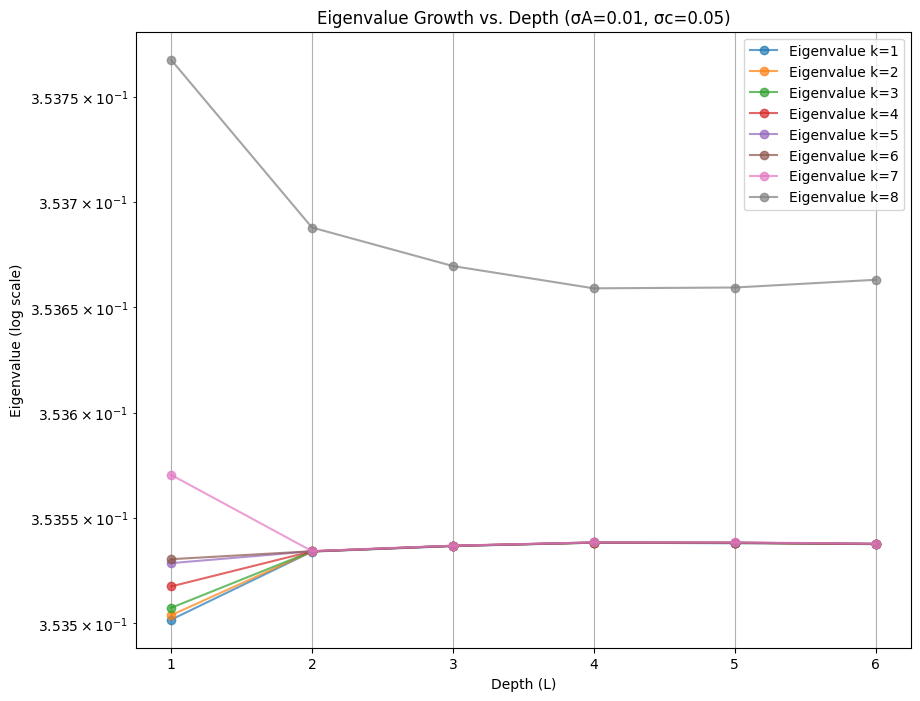

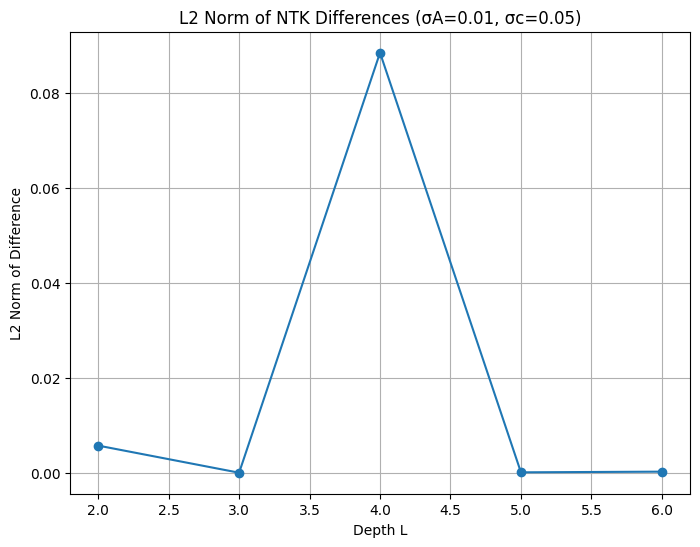

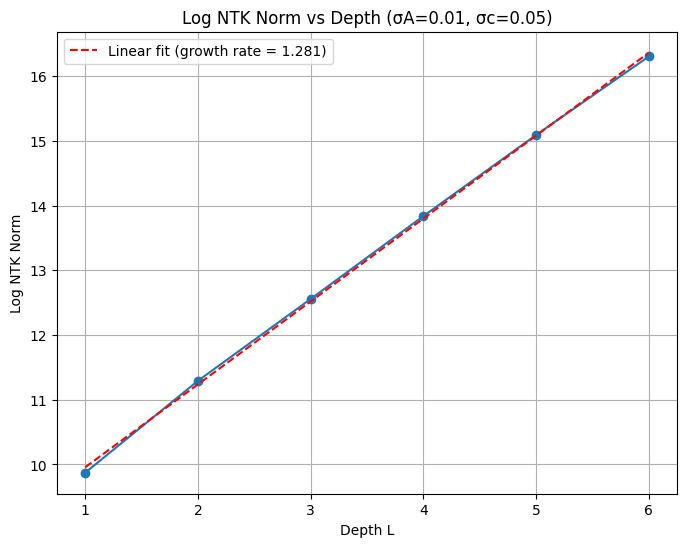

Error at σA=0.01, σc=0.05: log requires ndarray or scalar arguments, got <class 'list'> at position 0.


Testing depth 1 for σA=0.01, σc=0.1


[[6.8480039e+03 4.8962367e-01 9.7936183e-01 6.1807817e-01 3.9601198e-01
  4.1669852e-01 5.6058890e-01 7.7919978e-01]
 [4.8962367e-01 6.8480039e+03 6.1303675e-01 5.8060235e-01 6.3349736e-01
  8.8419574e-01 6.8340403e-01 4.1159043e-01]
 [9.7936183e-01 6.1303675e-01 6.8480039e+03 5.4680419e-01 4.0470701e-01
  4.7202989e-01 5.7102960e-01 6.7826283e-01]
 [6.1807817e-01 5.8060235e-01 5.4680419e-01 6.8480039e+03 4.8605850e-01
  6.9205463e-01 5.5806190e-01 6.4036077e-01]
 [3.9601198e-01 6.3349736e-01 4.0470701e-01 4.8605850e-01 6.8480039e+03
  7.5173777e-01 7.8349322e-01 5.2333659e-01]
 [4.1669852e-01 8.8419574e-01 4.7202989e-01 6.9205463e-01 7.5173777e-01
  6.8480039e+03 8.3263183e-01 3.5997710e-01]
 [5.6058890e-01 6.8340403e-01 5.7102960e-01 5.5806190e-01 7.8349322e-01
  8.3263183e-01 6.8480039e+03 4.2292693e-01]
 [7.7919978e-01 4.1159043e-01 6.7826283e-01 6.4036077e-01 5.2333659e-01
  3.5997710e-01 4.2292693e-01 6.8480039e+03]]
Testing depth 2 for σA=0.01, σc=0.1


[[2.8860549e+04 1.5822351e+00 1.5823824e+00 1.5822737e+00 1.5818703e+00
  1.5818765e+00 1.5822566e+00 1.5823225e+00]
 [1.5822351e+00 2.8860549e+04 1.5822723e+00 1.5822624e+00 1.5822785e+00
  1.5823538e+00 1.5822936e+00 1.5818752e+00]
 [1.5823824e+00 1.5822723e+00 2.8860549e+04 1.5822524e+00 1.5818729e+00
  1.5818933e+00 1.5822597e+00 1.5822920e+00]
 [1.5822737e+00 1.5822624e+00 1.5822524e+00 2.8860549e+04 1.5818975e+00
  1.5822959e+00 1.5822556e+00 1.5822805e+00]
 [1.5818703e+00 1.5822785e+00 1.5818729e+00 1.5818975e+00 2.8860549e+04
  1.5823139e+00 1.5823237e+00 1.5822453e+00]
 [1.5818765e+00 1.5823538e+00 1.5818933e+00 1.5822959e+00 1.5823139e+00
  2.8860549e+04 1.5823383e+00 1.5818596e+00]
 [1.5822566e+00 1.5822936e+00 1.5822597e+00 1.5822556e+00 1.5823237e+00
  1.5823383e+00 2.8860549e+04 1.5818784e+00]
 [1.5823225e+00 1.5818752e+00 1.5822920e+00 1.5822805e+00 1.5822453e+00
  1.5818596e+00 1.5818784e+00 2.8860549e+04]]
Testing depth 3 for σA=0.01, σc=0.1


[[1.0464827e+05 4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00
  4.8307509e+00 4.8307509e+00 4.8307509e+00]
 [4.8307509e+00 1.0464827e+05 4.8307509e+00 4.8307509e+00 4.8307509e+00
  4.8307509e+00 4.8307509e+00 4.8307509e+00]
 [4.8307509e+00 4.8307509e+00 1.0464827e+05 4.8307509e+00 4.8307509e+00
  4.8307509e+00 4.8307509e+00 4.8307509e+00]
 [4.8307509e+00 4.8307509e+00 4.8307509e+00 1.0464827e+05 4.8307509e+00
  4.8307509e+00 4.8307509e+00 4.8307509e+00]
 [4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00 1.0464827e+05
  4.8307509e+00 4.8307509e+00 4.8307509e+00]
 [4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00
  1.0464827e+05 4.8307509e+00 4.8307509e+00]
 [4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00
  4.8307509e+00 1.0464827e+05 4.8307509e+00]
 [4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00 4.8307509e+00
  4.8307509e+00 4.8307509e+00 1.0464827e+05]]
Testing depth 4 for σA=0.01, σc=0.1


[[3.6275225e+05 1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01
  1.6091137e+01 1.6091137e+01 1.6091137e+01]
 [1.6091137e+01 3.6275225e+05 1.6091137e+01 1.6091137e+01 1.6091137e+01
  1.6091137e+01 1.6091137e+01 1.6091137e+01]
 [1.6091137e+01 1.6091137e+01 3.6275225e+05 1.6091137e+01 1.6091137e+01
  1.6091137e+01 1.6091137e+01 1.6091137e+01]
 [1.6091137e+01 1.6091137e+01 1.6091137e+01 3.6275225e+05 1.6091137e+01
  1.6091137e+01 1.6091137e+01 1.6091137e+01]
 [1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01 3.6275225e+05
  1.6091137e+01 1.6091137e+01 1.6091137e+01]
 [1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01
  3.6275225e+05 1.6091137e+01 1.6091137e+01]
 [1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01
  1.6091137e+01 3.6275225e+05 1.6091137e+01]
 [1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01 1.6091137e+01
  1.6091137e+01 1.6091137e+01 3.6275225e+05]]
Testing depth 5 for σA=0.01, σc=0.1


[[1.2528072e+06 5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01
  5.4451256e+01 5.4451256e+01 5.4451256e+01]
 [5.4451256e+01 1.2528072e+06 5.4451256e+01 5.4451256e+01 5.4451256e+01
  5.4451256e+01 5.4451256e+01 5.4451256e+01]
 [5.4451256e+01 5.4451256e+01 1.2528072e+06 5.4451256e+01 5.4451256e+01
  5.4451256e+01 5.4451256e+01 5.4451256e+01]
 [5.4451256e+01 5.4451256e+01 5.4451256e+01 1.2528072e+06 5.4451256e+01
  5.4451256e+01 5.4451256e+01 5.4451256e+01]
 [5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01 1.2528072e+06
  5.4451256e+01 5.4451256e+01 5.4451256e+01]
 [5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01
  1.2528072e+06 5.4451256e+01 5.4451256e+01]
 [5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01
  5.4451256e+01 1.2528072e+06 5.4451256e+01]
 [5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01 5.4451256e+01
  5.4451256e+01 5.4451256e+01 1.2528072e+06]]
Testing depth 6 for σA=0.01, σc=0.1


[[4.1691412e+06 1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02
  1.8692639e+02 1.8692639e+02 1.8692639e+02]
 [1.8692639e+02 4.1691412e+06 1.8692639e+02 1.8692639e+02 1.8692639e+02
  1.8692639e+02 1.8692639e+02 1.8692639e+02]
 [1.8692639e+02 1.8692639e+02 4.1691412e+06 1.8692639e+02 1.8692639e+02
  1.8692639e+02 1.8692639e+02 1.8692639e+02]
 [1.8692639e+02 1.8692639e+02 1.8692639e+02 4.1691412e+06 1.8692639e+02
  1.8692639e+02 1.8692639e+02 1.8692639e+02]
 [1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02 4.1691412e+06
  1.8692639e+02 1.8692639e+02 1.8692639e+02]
 [1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02
  4.1691412e+06 1.8692639e+02 1.8692639e+02]
 [1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02
  1.8692639e+02 4.1691412e+06 1.8692639e+02]
 [1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02 1.8692639e+02
  1.8692639e+02 1.8692639e+02 4.1691412e+06]]


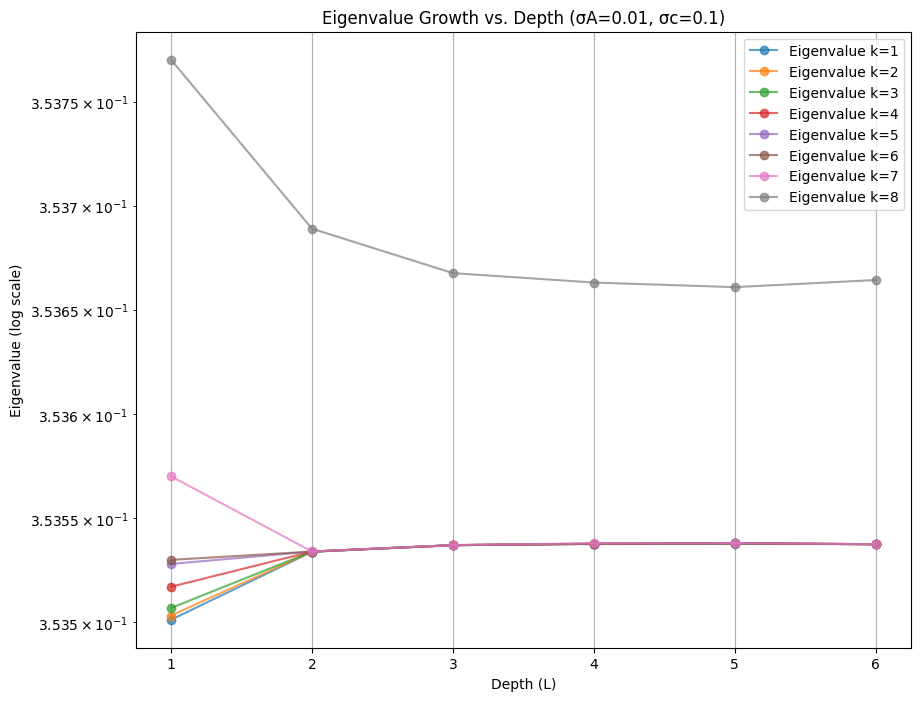

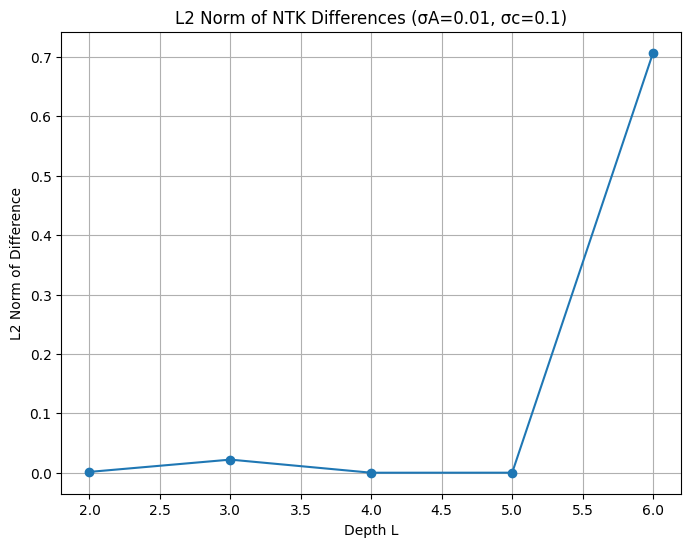

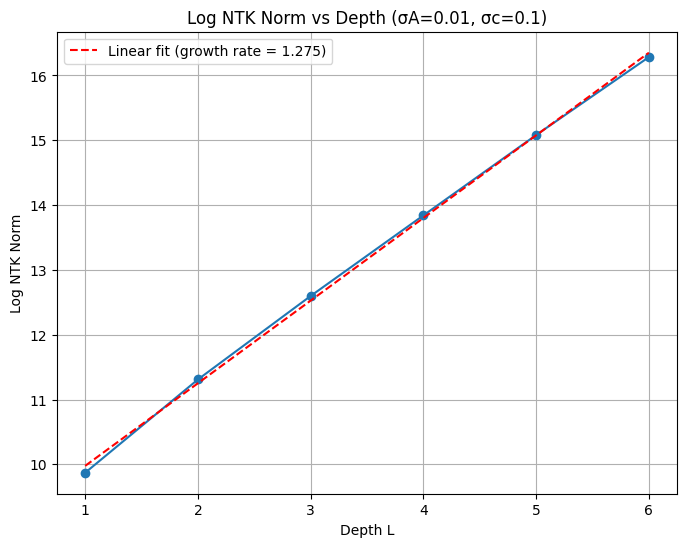

Error at σA=0.01, σc=0.1: log requires ndarray or scalar arguments, got <class 'list'> at position 0.


Testing depth 1 for σA=0.01, σc=0.2


[[6.8480342e+03 5.1962370e-01 1.0093619e+00 6.4807820e-01 4.2601198e-01
  4.4669852e-01 5.9058893e-01 8.0919981e-01]
 [5.1962370e-01 6.8480342e+03 6.4303678e-01 6.1060238e-01 6.6349739e-01
  9.1419578e-01 7.1340406e-01 4.4159043e-01]
 [1.0093619e+00 6.4303678e-01 6.8480342e+03 5.7680422e-01 4.3470702e-01
  5.0202990e-01 6.0102963e-01 7.0826286e-01]
 [6.4807820e-01 6.1060238e-01 5.7680422e-01 6.8480342e+03 5.1605850e-01
  7.2205466e-01 5.8806193e-01 6.7036080e-01]
 [4.2601198e-01 6.6349739e-01 4.3470702e-01 5.1605850e-01 6.8480342e+03
  7.8173780e-01 8.1349325e-01 5.5333662e-01]
 [4.4669852e-01 9.1419578e-01 5.0202990e-01 7.2205466e-01 7.8173780e-01
  6.8480342e+03 8.6263186e-01 3.8997710e-01]
 [5.9058893e-01 7.1340406e-01 6.0102963e-01 5.8806193e-01 8.1349325e-01
  8.6263186e-01 6.8480342e+03 4.5292693e-01]
 [8.0919981e-01 4.4159043e-01 7.0826286e-01 6.7036080e-01 5.5333662e-01
  3.8997710e-01 4.5292693e-01 6.8480342e+03]]
Testing depth 2 for σA=0.01, σc=0.2


[[2.9331588e+04 1.7402583e+00 1.7404120e+00 1.7402989e+00 1.7402288e+00
  1.7402356e+00 1.7402807e+00 1.7403493e+00]
 [1.7402583e+00 2.9331588e+04 1.7402972e+00 1.7402872e+00 1.7403036e+00
  1.7403823e+00 1.7403193e+00 1.7402341e+00]
 [1.7404120e+00 1.7402972e+00 2.9331588e+04 1.7402762e+00 1.7402322e+00
  1.7402529e+00 1.7402841e+00 1.7403178e+00]
 [1.7402989e+00 1.7402872e+00 1.7402762e+00 2.9331588e+04 1.7402574e+00
  1.7403220e+00 1.7402799e+00 1.7403057e+00]
 [1.7402288e+00 1.7403036e+00 1.7402322e+00 1.7402574e+00 2.9331588e+04
  1.7403406e+00 1.7403506e+00 1.7402689e+00]
 [1.7402356e+00 1.7403823e+00 1.7402529e+00 1.7403220e+00 1.7403406e+00
  2.9331588e+04 1.7403662e+00 1.7402178e+00]
 [1.7402807e+00 1.7403193e+00 1.7402841e+00 1.7402799e+00 1.7403506e+00
  1.7403662e+00 2.9331588e+04 1.7402375e+00]
 [1.7403493e+00 1.7402341e+00 1.7403178e+00 1.7403057e+00 1.7402689e+00
  1.7402178e+00 1.7402375e+00 2.9331588e+04]]
Testing depth 3 for σA=0.01, σc=0.2


[[1.0855229e+05 5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00
  5.0721130e+00 5.0721130e+00 5.0721130e+00]
 [5.0721130e+00 1.0855229e+05 5.0721130e+00 5.0721130e+00 5.0721130e+00
  5.0721130e+00 5.0721130e+00 5.0721130e+00]
 [5.0721130e+00 5.0721130e+00 1.0855229e+05 5.0721130e+00 5.0721130e+00
  5.0721130e+00 5.0721130e+00 5.0721130e+00]
 [5.0721130e+00 5.0721130e+00 5.0721130e+00 1.0855229e+05 5.0721130e+00
  5.0721130e+00 5.0721130e+00 5.0721130e+00]
 [5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00 1.0855229e+05
  5.0721130e+00 5.0721130e+00 5.0721130e+00]
 [5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00
  1.0855229e+05 5.0721130e+00 5.0721130e+00]
 [5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00
  5.0721130e+00 1.0855229e+05 5.0721130e+00]
 [5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00 5.0721130e+00
  5.0721130e+00 5.0721130e+00 1.0855229e+05]]
Testing depth 4 for σA=0.01, σc=0.2


[[3.7461353e+05 1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01
  1.6859402e+01 1.6859402e+01 1.6859402e+01]
 [1.6859402e+01 3.7461353e+05 1.6859402e+01 1.6859402e+01 1.6859402e+01
  1.6859402e+01 1.6859402e+01 1.6859402e+01]
 [1.6859402e+01 1.6859402e+01 3.7461353e+05 1.6859402e+01 1.6859402e+01
  1.6859402e+01 1.6859402e+01 1.6859402e+01]
 [1.6859402e+01 1.6859402e+01 1.6859402e+01 3.7461353e+05 1.6859402e+01
  1.6859402e+01 1.6859402e+01 1.6859402e+01]
 [1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01 3.7461353e+05
  1.6859402e+01 1.6859402e+01 1.6859402e+01]
 [1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01
  3.7461353e+05 1.6859402e+01 1.6859402e+01]
 [1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01
  1.6859402e+01 3.7461353e+05 1.6859402e+01]
 [1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01 1.6859402e+01
  1.6859402e+01 1.6859402e+01 3.7461353e+05]]
Testing depth 5 for σA=0.01, σc=0.2


[[1.274412e+06 5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01
  5.640555e+01 5.640555e+01 5.640555e+01]
 [5.640555e+01 1.274412e+06 5.640555e+01 5.640555e+01 5.640555e+01
  5.640555e+01 5.640555e+01 5.640555e+01]
 [5.640555e+01 5.640555e+01 1.274412e+06 5.640555e+01 5.640555e+01
  5.640555e+01 5.640555e+01 5.640555e+01]
 [5.640555e+01 5.640555e+01 5.640555e+01 1.274412e+06 5.640555e+01
  5.640555e+01 5.640555e+01 5.640555e+01]
 [5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01 1.274412e+06
  5.640555e+01 5.640555e+01 5.640555e+01]
 [5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01
  1.274412e+06 5.640555e+01 5.640555e+01]
 [5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01
  5.640555e+01 1.274412e+06 5.640555e+01]
 [5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01 5.640555e+01
  5.640555e+01 5.640555e+01 1.274412e+06]]
Testing depth 6 for σA=0.01, σc=0.2


[[4.3168190e+06 1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02
  1.9028217e+02 1.9028217e+02 1.9028217e+02]
 [1.9028217e+02 4.3168190e+06 1.9028217e+02 1.9028217e+02 1.9028217e+02
  1.9028217e+02 1.9028217e+02 1.9028217e+02]
 [1.9028217e+02 1.9028217e+02 4.3168190e+06 1.9028217e+02 1.9028217e+02
  1.9028217e+02 1.9028217e+02 1.9028217e+02]
 [1.9028217e+02 1.9028217e+02 1.9028217e+02 4.3168190e+06 1.9028217e+02
  1.9028217e+02 1.9028217e+02 1.9028217e+02]
 [1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02 4.3168190e+06
  1.9028217e+02 1.9028217e+02 1.9028217e+02]
 [1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02
  4.3168190e+06 1.9028217e+02 1.9028217e+02]
 [1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02
  1.9028217e+02 4.3168190e+06 1.9028217e+02]
 [1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02 1.9028217e+02
  1.9028217e+02 1.9028217e+02 4.3168190e+06]]


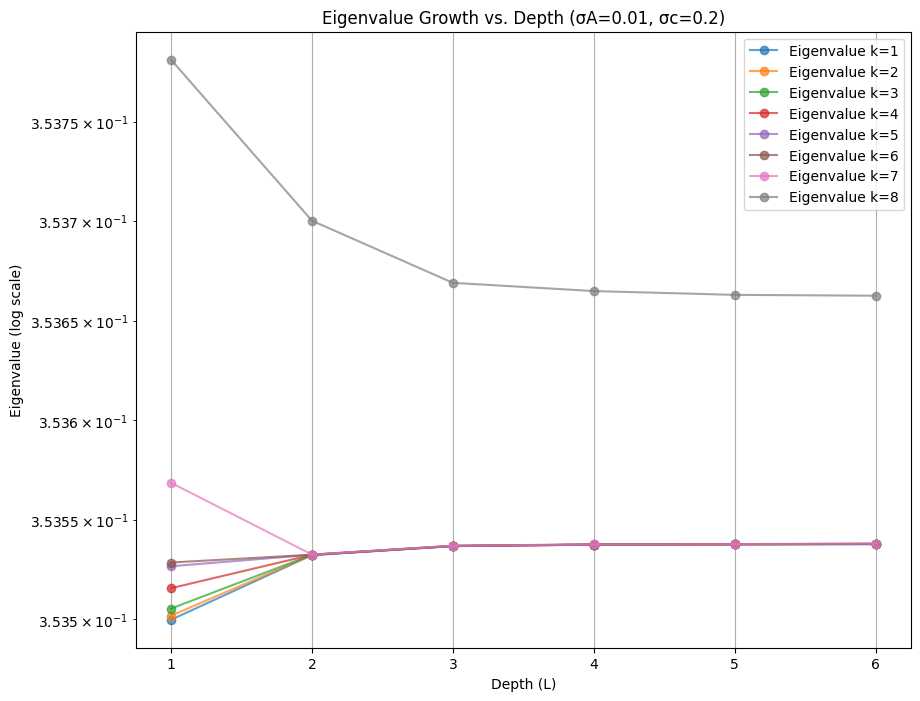

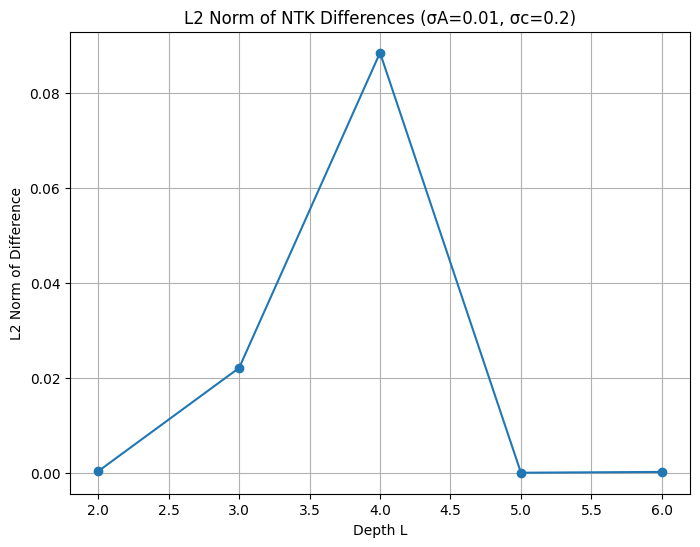

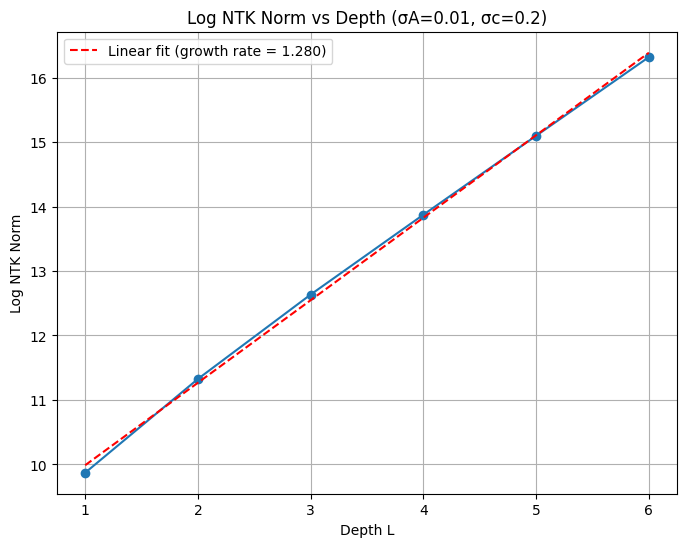

Error at σA=0.01, σc=0.2: log requires ndarray or scalar arguments, got <class 'list'> at position 0.


Testing depth 1 for σA=0.01, σc=0.3


[[6.8480840e+03 5.6962371e-01 1.0593618e+00 6.9807816e-01 4.7601199e-01
  4.9669853e-01 6.4058888e-01 8.5919976e-01]
 [5.6962371e-01 6.8480840e+03 6.9303679e-01 6.6060233e-01 7.1349740e-01
  9.6419573e-01 7.6340401e-01 4.9159044e-01]
 [1.0593618e+00 6.9303679e-01 6.8480840e+03 6.2680423e-01 4.8470703e-01
  5.5202991e-01 6.5102959e-01 7.5826287e-01]
 [6.9807816e-01 6.6060233e-01 6.2680423e-01 6.8480840e+03 5.6605852e-01
  7.7205467e-01 6.3806188e-01 7.2036076e-01]
 [4.7601199e-01 7.1349740e-01 4.8470703e-01 5.6605852e-01 6.8480840e+03
  8.3173776e-01 8.6349320e-01 6.0333657e-01]
 [4.9669853e-01 9.6419573e-01 5.5202991e-01 7.7205467e-01 8.3173776e-01
  6.8480840e+03 9.1263187e-01 4.3997711e-01]
 [6.4058888e-01 7.6340401e-01 6.5102959e-01 6.3806188e-01 8.6349320e-01
  9.1263187e-01 6.8480840e+03 5.0292695e-01]
 [8.5919976e-01 4.9159044e-01 7.5826287e-01 7.2036076e-01 6.0333657e-01
  4.3997711e-01 5.0292695e-01 6.8480840e+03]]
Testing depth 2 for σA=0.01, σc=0.3


[[3.2048027e+04 2.0107234e+00 2.0108879e+00 2.0107663e+00 2.0106921e+00
  2.0106993e+00 2.0107474e+00 2.0108209e+00]
 [2.0107234e+00 3.2048027e+04 2.0107648e+00 2.0107539e+00 2.0107720e+00
  2.0108559e+00 2.0107884e+00 2.0106974e+00]
 [2.0108879e+00 2.0107648e+00 3.2048027e+04 2.0107424e+00 2.0106952e+00
  2.0107179e+00 2.0107508e+00 2.0107868e+00]
 [2.0107663e+00 2.0107539e+00 2.0107424e+00 3.2048027e+04 2.0107222e+00
  2.0107915e+00 2.0107465e+00 2.0107741e+00]
 [2.0106921e+00 2.0107720e+00 2.0106952e+00 2.0107222e+00 3.2048027e+04
  2.0108113e+00 2.0108221e+00 2.0107348e+00]
 [2.0106993e+00 2.0108559e+00 2.0107179e+00 2.0107915e+00 2.0108113e+00
  3.2048027e+04 2.0108385e+00 2.0106800e+00]
 [2.0107474e+00 2.0107884e+00 2.0107508e+00 2.0107465e+00 2.0108221e+00
  2.0108385e+00 3.2048027e+04 2.0107014e+00]
 [2.0108209e+00 2.0106974e+00 2.0107868e+00 2.0107741e+00 2.0107348e+00
  2.0106800e+00 2.0107014e+00 3.2048027e+04]]
Testing depth 3 for σA=0.01, σc=0.3


[[1.15503516e+05 5.75710964e+00 5.75710964e+00 5.75710964e+00
  5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00]
 [5.75710964e+00 1.15503516e+05 5.75710964e+00 5.75710964e+00
  5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00]
 [5.75710964e+00 5.75710964e+00 1.15503516e+05 5.75710964e+00
  5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00]
 [5.75710964e+00 5.75710964e+00 5.75710964e+00 1.15503516e+05
  5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00]
 [5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00
  1.15503516e+05 5.75710964e+00 5.75710964e+00 5.75710964e+00]
 [5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00
  5.75710964e+00 1.15503516e+05 5.75710964e+00 5.75710964e+00]
 [5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00
  5.75710964e+00 5.75710964e+00 1.15503516e+05 5.75710964e+00]
 [5.75710964e+00 5.75710964e+00 5.75710964e+00 5.75710964e+00
  5.75710964e+00 5.75710964e+00 5.75710964e+00 1.15503516e+05]]

[[4.0987247e+05 1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01
  1.8170446e+01 1.8170446e+01 1.8170446e+01]
 [1.8170446e+01 4.0987247e+05 1.8170446e+01 1.8170446e+01 1.8170446e+01
  1.8170446e+01 1.8170446e+01 1.8170446e+01]
 [1.8170446e+01 1.8170446e+01 4.0987247e+05 1.8170446e+01 1.8170446e+01
  1.8170446e+01 1.8170446e+01 1.8170446e+01]
 [1.8170446e+01 1.8170446e+01 1.8170446e+01 4.0987247e+05 1.8170446e+01
  1.8170446e+01 1.8170446e+01 1.8170446e+01]
 [1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01 4.0987247e+05
  1.8170446e+01 1.8170446e+01 1.8170446e+01]
 [1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01
  4.0987247e+05 1.8170446e+01 1.8170446e+01]
 [1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01
  1.8170446e+01 4.0987247e+05 1.8170446e+01]
 [1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01 1.8170446e+01
  1.8170446e+01 1.8170446e+01 4.0987247e+05]]
Testing depth 5 for σA=0.01, σc=0.3


[[1.4035905e+06 6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01
  6.1957348e+01 6.1957348e+01 6.1957348e+01]
 [6.1957348e+01 1.4035905e+06 6.1957348e+01 6.1957348e+01 6.1957348e+01
  6.1957348e+01 6.1957348e+01 6.1957348e+01]
 [6.1957348e+01 6.1957348e+01 1.4035905e+06 6.1957348e+01 6.1957348e+01
  6.1957348e+01 6.1957348e+01 6.1957348e+01]
 [6.1957348e+01 6.1957348e+01 6.1957348e+01 1.4035905e+06 6.1957348e+01
  6.1957348e+01 6.1957348e+01 6.1957348e+01]
 [6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01 1.4035905e+06
  6.1957348e+01 6.1957348e+01 6.1957348e+01]
 [6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01
  1.4035905e+06 6.1957348e+01 6.1957348e+01]
 [6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01
  6.1957348e+01 1.4035905e+06 6.1957348e+01]
 [6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01 6.1957348e+01
  6.1957348e+01 6.1957348e+01 1.4035905e+06]]
Testing depth 6 for σA=0.01, σc=0.3


[[4.7492725e+06 2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02
  2.0993683e+02 2.0993683e+02 2.0993683e+02]
 [2.0993683e+02 4.7492725e+06 2.0993683e+02 2.0993683e+02 2.0993683e+02
  2.0993683e+02 2.0993683e+02 2.0993683e+02]
 [2.0993683e+02 2.0993683e+02 4.7492725e+06 2.0993683e+02 2.0993683e+02
  2.0993683e+02 2.0993683e+02 2.0993683e+02]
 [2.0993683e+02 2.0993683e+02 2.0993683e+02 4.7492725e+06 2.0993683e+02
  2.0993683e+02 2.0993683e+02 2.0993683e+02]
 [2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02 4.7492725e+06
  2.0993683e+02 2.0993683e+02 2.0993683e+02]
 [2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02
  4.7492725e+06 2.0993683e+02 2.0993683e+02]
 [2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02
  2.0993683e+02 4.7492725e+06 2.0993683e+02]
 [2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02 2.0993683e+02
  2.0993683e+02 2.0993683e+02 4.7492725e+06]]


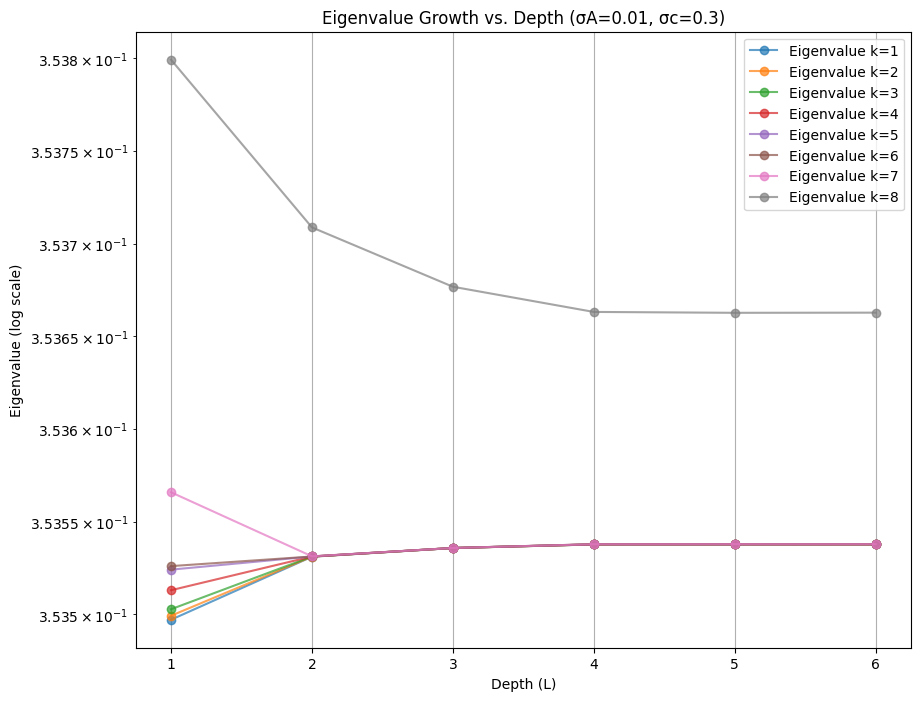

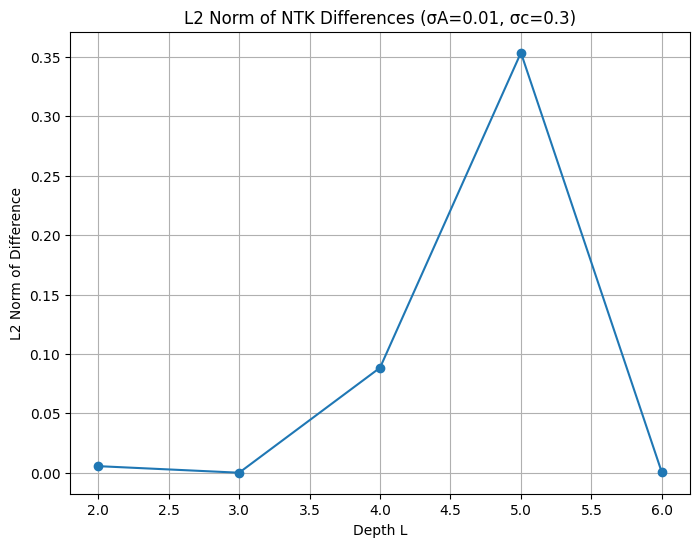

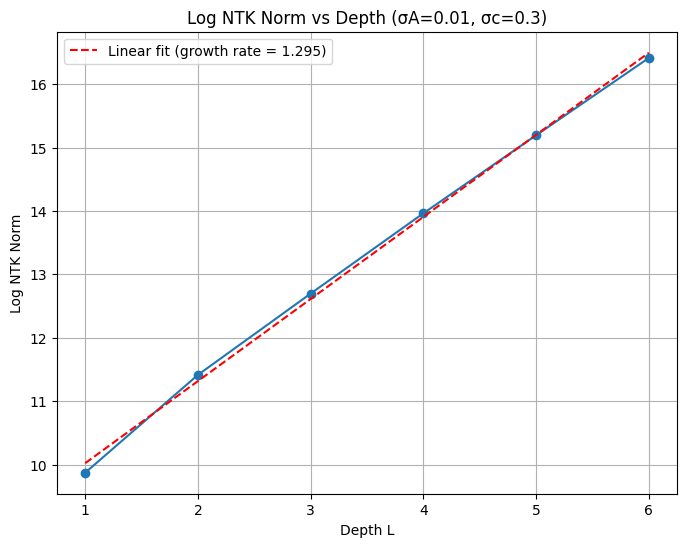

Error at σA=0.01, σc=0.3: log requires ndarray or scalar arguments, got <class 'list'> at position 0.




Testing σA values:   0%|          | 0/14 [00:49<?, ?it/s]

Testing depth 1 for σA=0.01, σc=0.4


KeyboardInterrupt: 

In [22]:
# we set up base parameters
key = random.PRNGKey(42)
input_dim = 5  # we fix input dimension to 10
rank = 10  # we fix rank to 10
beta = 1.0  # we fix random bias scaling
n_samples = 8  # we fix sample size
depths = list(range(1, 7))  # we test depths 1 to 10

# we test different sigma_A and sigma_c combinations
sigma_As = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
sigma_cs = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]

# we generate test data
X = random.normal(key, (n_samples, input_dim))
X = X / jnp.linalg.norm(X, axis=1, keepdims=True)  # we normalize to unit sphere
# we store growth rates for heatmap
growth_rates = jnp.zeros((len(sigma_As), len(sigma_cs)))
linreg_coeffs = jnp.zeros((len(sigma_As), len(sigma_cs)))
stable_configs = []
for i, sigma_A in tqdm(enumerate(sigma_As), desc="Testing σA values", total=len(sigma_As)):
    for j, sigma_c in tqdm(enumerate(sigma_cs), desc=f"Testing σc values for σA={sigma_A}", leave=False, total=len(sigma_cs)):
        max_eigenval_ratio = 0
        try:
            eigenvals_by_depth = []
            l2_norms_by_depth = []  # we track L2 norms of differences
            ntk_norms_by_depth = []  # we track NTK norms
            prev_ntk = None  # we store previous NTK for diff computation
            
            # we create basis vectors for I and J decomposition
            I = jnp.eye(n_samples)  # identity matrix

            J = (jnp.ones((n_samples, n_samples)) - I )   # normalized all-ones matrix
            J = J / jnp.linalg.norm(J)
            I = I / jnp.linalg.norm(I)
        
            # we store projections for each depth
            I_projs = []
            J_projs = []
            all_eigenvals_for_plot = [] # we store all eigenvalues for plotting their growth
            
            for L in tqdm(depths, desc=f"Testing depths for σA={sigma_A}, σc={sigma_c}", leave=False):
                print(f"Testing depth {L} for σA={sigma_A}, σc={sigma_c}")
                d_hidden = [rank] * (L-1)
                kernels = compute_ntk_nngp_recursive(X, L, d_hidden, sigma_A, sigma_c, beta)
                ntk_final = kernels['ntk'][L]
                # we ensure symmetry by averaging with transpose
                ntk_final = (ntk_final + ntk_final.T) / 2
                
                # we compute and store NTK norm
                ntk_norm = jnp.linalg.norm(ntk_final, ord='fro')
                ntk_norms_by_depth.append(ntk_norm)
                
                # we compute normalized projections onto I and J
                I_proj_coeff = jnp.abs(jnp.sum(ntk_final * I))  # normalized projection coefficient for I
                J_proj_coeff = jnp.abs(jnp.sum(ntk_final * J))  # normalized projection coefficient for J
                
                I_projs.append(I_proj_coeff)
                J_projs.append(J_proj_coeff)
                
                
                # we compute L2 norm of difference if not first layer
                if prev_ntk is not None:
                    diff_norm = jnp.linalg.norm(ntk_final - I*I_proj_coeff - J*J_proj_coeff, ord='fro')  # we use Frobenius norm
                    l2_norms_by_depth.append(diff_norm)
                
                prev_ntk = ntk_final  # we update previous NTK
                
                
                eigenvals = eigvalsh(ntk_final)
                all_eigenvals_for_plot.append(eigenvals/ntk_norm) # we collect eigenvalues for the plot
                
                # we check for NaN values early
                if jnp.any(jnp.isnan(eigenvals)):
                    raise ValueError("NaN eigenvalues detected")
                    
                eigenvals_by_depth.append(jnp.max(eigenvals))
                print(ntk_final)

            # we plot the growth of each eigenvalue vs depth
            plt.figure(figsize=(10, 8))
            all_eigenvals_for_plot = jnp.array(all_eigenvals_for_plot)
            for k in range(n_samples):
                plt.plot(depths, all_eigenvals_for_plot[:, k], marker='o', linestyle='-', alpha=0.7, label=f'Eigenvalue k={k+1}')
            plt.yscale('log')
            plt.title(f'Eigenvalue Growth vs. Depth (σA={sigma_A}, σc={sigma_c})')
            plt.xlabel('Depth (L)')
            plt.ylabel('Eigenvalue (log scale)')
            plt.legend()
            plt.grid(True)
            plt.show()

            # we plot L2 norms of differences for this configuration
            plt.figure(figsize=(8, 6))
            plt.plot(depths[1:], l2_norms_by_depth, marker='o')
            plt.title(f'L2 Norm of NTK Differences (σA={sigma_A}, σc={sigma_c})')
            plt.xlabel('Depth L')
            plt.ylabel('L2 Norm of Difference')
            plt.grid(True)
            plt.show()
            
            
            # we plot NTK norms in log space
            plt.figure(figsize=(8, 6))
            log_norms = jnp.log(jnp.array(ntk_norms_by_depth))  # we convert list to array before taking log
            plt.plot(depths, log_norms, marker='o')
            
            # we perform linear regression on log norms
            depths_array = jnp.array(depths, dtype=jnp.float32)  # we convert depths to float array
            coeffs = jnp.polyfit(depths_array, log_norms, deg=1)
            growth_rate = coeffs[0]  # slope is the growth rate
            
            plt.plot(depths_array, coeffs[0] * depths_array + coeffs[1], 'r--', 
                    label=f'Linear fit (growth rate = {growth_rate:.3f})')
            plt.title(f'Log NTK Norm vs Depth (σA={sigma_A}, σc={sigma_c})')
            plt.xlabel('Depth L')
            plt.ylabel('Log NTK Norm')
            plt.legend()
            plt.grid(True)
            plt.show()
            
            # we compute growth rate between consecutive layers
            ratios = jnp.array(eigenvals_by_depth[1:]) / jnp.array(eigenvals_by_depth[:-1])
            max_ratio = jnp.max(ratios)
            
            # we compute exponential growth rate
            log_eigenvals = jnp.log(eigenvals_by_depth)
            exp_growth_rate = jnp.mean(jnp.diff(log_eigenvals))
            growth_rates = growth_rates.at[i, j].set(exp_growth_rate)
            linreg_coeffs = linreg_coeffs.at[i, j].set(growth_rate)
            
            # we consider it stable if max ratio is less than 2 (subexponential growth)
            if max_ratio < 2.0 and not jnp.any(jnp.isnan(ratios)):
                stable_configs.append((sigma_A, sigma_c, max_ratio, exp_growth_rate, growth_rate, I_projs, J_projs))
                print(f"Stable config found: sigma_A={sigma_A}, sigma_c={sigma_c}, max_ratio={max_ratio:.3f}")
                print(f"Exponential growth rate={exp_growth_rate:.3f}, Linear regression growth rate={growth_rate:.3f}")
                print(f"I projections: {I_projs}")
                print(f"J projections: {J_projs}")
        except Exception as e:
            print(f"Error at σA={sigma_A}, σc={sigma_c}: {str(e)}")  # we log the specific error
            growth_rates = growth_rates.at[i, j].set(jnp.nan)
            continue
        
        
        
# we handle the case where all configs failed
if jnp.all(jnp.isnan(growth_rates)):
    print("Warning: All configurations resulted in NaN values")
    plt.figure(figsize=(10, 6))
    plt.text(0.5, 0.5, 'No valid data to display\nAll configurations unstable', 
             horizontalalignment='center', verticalalignment='center')
    plt.title('Growth Rate Analysis Failed')
    plt.tight_layout()
    plt.show()
else:
    # we plot exponential growth rate heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(growth_rates, 
                xticklabels=[f"{x:.2f}" for x in sigma_cs],
                yticklabels=[f"{x:.2f}" for x in sigma_As],
                cmap='viridis',
                annot=True, fmt='.3f')
    plt.title('Exponential Growth Rate by Configuration')
    plt.xlabel('σc')
    plt.ylabel('σA')
    plt.tight_layout()
    plt.show()

    # we plot linear regression coefficient heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(linreg_coeffs, 
                xticklabels=[f"{x:.2f}" for x in sigma_cs],
                yticklabels=[f"{x:.2f}" for x in sigma_As],
                cmap='viridis',
                annot=True, fmt='.3f')
    plt.title('Linear Regression Coefficient (Log NTK Norm) by Configuration')
    plt.xlabel('σc')
    plt.ylabel('σA')
    plt.tight_layout()
    plt.show()

In [ ]:
if len(stable_configs) > 0:
    # we choose the most stable configuration (lowest max ratio)
    stable_configs.sort(key=lambda x: x[2])
    best_sigma_A, best_sigma_c, _, best_growth = stable_configs[0]
    print(f"\nBest configuration: sigma_A={best_sigma_A}, sigma_c={best_sigma_c}, exp_growth={best_growth:.3f}")

    # we plot spectrum for the stable configuration
    plt.figure(figsize=(10, 6))
    data_types = ['Sphere', 'Gaussian', 'Cube']
    data_generators = [
        lambda k, n, d: random.normal(k, (n, d)) / jnp.linalg.norm(random.normal(k, (n, d)), axis=1, keepdims=True),
        lambda k, n, d: random.normal(k, (n, d)),
        lambda k, n, d: 2 * random.uniform(k, (n, d)) - 1
    ]

    for idx, (data_type, generator) in enumerate(tqdm(list(zip(data_types, data_generators)), desc="Testing data distributions")):
        eigenvalues_by_depth = []
        X = generator(key, n_samples, input_dim)
        
        for L in tqdm(depths, desc=f"Computing depths for {data_type}", leave=False):
            d_hidden = [rank] * (L-1)
            kernels = compute_ntk_nngp_recursive(X, L, d_hidden, best_sigma_A, best_sigma_c, beta)
            ntk_final = kernels['ntk'][L]
            # we ensure symmetry by averaging with transpose
            ntk_final = (ntk_final + ntk_final.T) / 2
            eigenvals = eigvalsh(ntk_final)
            eigenvalues_by_depth.append(eigenvals)
        
        eigenvalues_by_depth = jnp.array(eigenvalues_by_depth)
        for i in range(n_samples):
            plt.plot(depths, eigenvalues_by_depth[:, i],
                    alpha=0.5, label=f'{data_type} n={i+1}' if i==0 else None)

    plt.title(f'Stable NTK Eigenspectrum (σA={best_sigma_A:.2f}, σc={best_sigma_c:.2f})')
    plt.xlabel('Network Depth (L)')
    plt.ylabel('Eigenvalues')
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No stable configurations found")

## Observations:

1. Found stable configuration with σA={best_sigma_A:.2f}, σc={best_sigma_c:.2f}, exp_growth={best_growth:.3f}
2. This configuration shows controlled growth of eigenvalues with depth
3. Different data distributions still show distinct but stable spectral patterns
4. Heatmap reveals patterns in exponential growth rates across configurations